### 라이브러리를 이용해서 데이터를 수집
- yahoo finance
    - 글로벌 주식 및 회사 데이터를 로드
- 한국거래소 정보를 가져오는 라이브러리(pykrx)
    - 한국 회사들에 대한 데이터 로드

- 실시간 데이터는 불가능
    - pykrx는 일별 주식 가격 조회
    - yfinance는 시간별로 조회 가능 (기간이 굉장히 짧음), 실시간은 아님(한 20분 ~ 30분 정도의 차이가 존재)
    
- 실시간 데이터를 로드하려면 증권사 api 사용
    - 증권사 계정 존재(개인 계정 가능)
        - 은행 계좌 등록
        - 별도의 api key 발급

In [ ]:
# 라이브러리 설치
# !pip install yfinance pykrx

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ----------------------- ---------------- 1.3/2.2 MB 6.1 MB/s eta 0:00:01
   ---------------------------------------- 2.2/2.2 MB 6.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------------------------- -------- 1.3/1.7 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 5.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---- ----------------------------------- 1.3/12.6 MB 6.7 MB/s eta 0:00:02
   ------ --------------------------------- 2.1/12.6 MB 5.3 MB/s eta 0:00:02
   ---------- ----------------------------- 3.4/12.6 MB 5.8 MB/s eta 0:00:02
   --------------- ------------------------ 5.0/12.6 MB 6.2 MB/s eta 0:00:02
   -------------------- ------------------- 6.6/12.6 MB 6.5 MB/s eta 0:00:01
 

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
basemap 1.4.1 requires numpy<1.27,>=1.21; python_version >= "3.8", but you have numpy 2.4.4 which is incompatible.
scipy 1.11.2 requires numpy<1.28.0,>=1.21.6, but you have numpy 2.4.4 which is incompatible.
tensorboard 2.15.1 requires protobuf<4.24,>=3.19.6, but you have protobuf 5.29.4 which is incompatible.
tensorflow-intel 2.15.0 requires numpy<2.0.0,>=1.23.5, but you have numpy 2.4.4 which is incompatible.
tensorflow-intel 2.15.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.20.3, but you have protobuf 5.29.4 which is incompatible.
thinc 8.3.2 requires numpy<2.1.0,>=2.0.0; python_version >= "3.9", but you have numpy 2.4.4 which is incompatible.

[notice] A new r

In [2]:
# 라이브러리 로드
import yfinance as yf

In [5]:
# 특정 종목의 데이터를 가져온다.
ticker1 = '005930.KS'
samsung = yf.Ticker(ticker1)

In [9]:
# history() ->
# 주요 매개변수 period(기간 설정) -> 기본값 1d -> 5d, 1mo, 3mo, 6mo, 1y, 2y
# interval(주기) ->
samsung.history(period='5d',interval = '1m')

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2026-04-17 09:00:00+09:00,217000.0,218000.0,217000.0,217250.0,0,0.0,0.0
2026-04-17 09:01:00+09:00,217250.0,218000.0,216500.0,216500.0,138510,0.0,0.0
2026-04-17 09:02:00+09:00,217000.0,217500.0,216500.0,216500.0,64171,0.0,0.0
2026-04-17 09:03:00+09:00,216500.0,217000.0,216000.0,216000.0,132867,0.0,0.0
2026-04-17 09:04:00+09:00,216500.0,216500.0,216000.0,216000.0,80982,0.0,0.0
...,...,...,...,...,...,...,...
2026-04-23 14:55:00+09:00,224500.0,225000.0,224500.0,224500.0,21110,0.0,0.0
2026-04-23 14:56:00+09:00,224500.0,225000.0,224500.0,224500.0,18468,0.0,0.0
2026-04-23 14:57:00+09:00,224500.0,225000.0,224500.0,224500.0,22205,0.0,0.0


In [10]:
# 라이브러리로 이용중이지만 크롤링 -> 과도하게 사용시 ip ban 발생

In [11]:
# 배당금 주식 분할 정보
samsung.actions

,Dividends,Stock Splits
Date,,
2006-06-29 00:00:00+09:00,10.0,0.0
2006-12-27 00:00:00+09:00,100.0,0.0
2007-06-28 00:00:00+09:00,10.0,0.0
2007-12-27 00:00:00+09:00,150.0,0.0
2008-06-27 00:00:00+09:00,10.0,0.0
2008-12-29 00:00:00+09:00,100.0,0.0
2009-06-29 00:00:00+09:00,10.0,0.0
2009-12-29 00:00:00+09:00,150.0,0.0
2010-06-29 00:00:00+09:00,100.0,0.0


In [17]:
# pykrx 라이브러리
from pykrx import stock

In [16]:
# 특정 날짜의 상장 종목을 모두 확인
tickers = stock.get_market_ticker_list('20260422',market='KOSPI')
tickers

Error occurred in get_market_ticker_and_name: Expecting value: line 1 column 1 (char 0)


[]

In [19]:
stock.get_market_ticker_name('005930')

'삼성전자'

In [20]:
# OHLCV 확인
stock.get_market_ohlcv('20260101','20260423','005930')

,시가,고가,저가,종가,거래량,등락률
날짜,,,,,,
2026-01-02,120200,128500,120200,128500,30463279,7.172644
2026-01-05,134600,138600,133600,138100,42863376,7.470817
2026-01-06,135300,139300,132700,138900,45321341,0.579290
2026-01-07,143500,144400,137600,141000,46317413,1.511879
2026-01-08,138300,144500,138300,138800,41449329,-1.560284
...,...,...,...,...,...,...
2026-04-17,217000,218000,215000,216000,18079322,-0.689655
2026-04-20,214500,219000,213000,214500,17107741,-0.694444
2026-04-21,218000,220000,216000,219000,16752132,2.097902


In [ ]:
# !pip install finance-datareader


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
import FinanceDataReader as fdr

In [26]:
# KRX 전체 종목 확인
tickers = fdr.StockListing('KRX')

In [27]:
tickers.head(5)

,Unnamed: 0,Code,ISU_CD,Name,Market,Dept,Close,ChangeCode,Changes,ChagesRatio,Open,High,Low,Volume,Amount,Marcap,Stocks,MarketId
0,0,005930,KR7005930003,삼성전자,KOSPI,NaN,224500,1,7000,3.22,223000,229500,216000,34525485,7739982934106,1312489547496000,5846278608,STK
1,1,000660,KR7000660001,SK하이닉스,KOSPI,NaN,1225000,1,2000,0.16,1220000,1267000,1183000,5343871,6558016801135,873060397125000,712702365,STK
2,2,005935,KR7005931001,삼성전자우,KOSPI,NaN,156200,1,4900,3.24,154500,160800,151500,4642008,729556414700,125330381908600,802371203,STK
3,3,373220,KR7373220003,LG에너지솔루션,KOSPI,NaN,466500,2,-18000,-3.72,481500,484000,460000,529996,248030525500,109161000000000,234000000,STK
4,4,005380,KR7005380001,현대차,KOSPI,NaN,532000,2,-9000,-1.66,547000,551000,525000,1089561,585221220000,108931131512000,204757766,STK


In [28]:
# 특정 종목의 가격 데이터 확인
fdr.DataReader('005930','2026-01-01','2026-04-23')

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2026-01-02,120200,128500,120200,128500,30463279,0.071726
2026-01-05,134600,138600,133600,138100,42863376,0.074708
2026-01-06,135300,139300,132700,138900,45321341,0.005793
2026-01-07,143500,144400,137600,141000,46317413,0.015119
2026-01-08,138300,144500,138300,138800,41449329,-0.015603
...,...,...,...,...,...,...
2026-04-17,217000,218000,215000,216000,18079322,-0.006897
2026-04-20,214500,219000,213000,214500,17107741,-0.006944
2026-04-21,218000,220000,216000,219000,16752132,0.020979


In [ ]:
# 지수 확인
# 코스피 KS11, 코스탁 KQ11
fdr.DataReader('KS11','2026-01-01')

,Close,UpDown,Comp,Change,Open,High,Low,Volume,Amount,MarCap
Date,,,,,,,,,,
2026-01-02,4309.63,1,95.46,0.0227,4224.53,4313.55,4216.68,406339246,17521809108064,3558736495078057
2026-01-05,4457.52,1,147.89,0.0343,4385.92,4457.52,4381.93,513869696,22783803354664,3683501014645836
2026-01-06,4525.48,1,67.96,0.0152,4446.08,4525.48,4395.00,498391270,25518237182834,3738188652369778
2026-01-07,4551.06,1,25.58,0.0057,4566.34,4611.72,4488.20,553653981,29139900200735,3759722548753830
2026-01-08,4552.37,1,1.31,0.0003,4531.46,4622.32,4527.50,440086040,27476981855641,3759062721637169
...,...,...,...,...,...,...,...,...,...,...
2026-04-17,6191.92,2,-34.13,-0.0055,6227.33,6230.32,6159.88,689739734,24619562398516,5076379137907436
2026-04-20,6219.09,1,27.17,0.0044,6213.92,6278.36,6176.75,692878455,23576476166973,5097490312334976
2026-04-21,6388.47,1,169.38,0.0272,6302.54,6388.47,6302.54,792021737,31105972365121,5236207009794765


In [30]:
fdr.DataReader('AAPL','2026-01-01')

,Open,High,Low,Close,Volume,Adj Close
2025-12-31,273.059998,273.679993,271.750000,271.859985,27293600,271.605835
2026-01-02,272.260010,277.839996,269.000000,271.010010,37838100,270.756653
2026-01-05,270.640015,271.510010,266.140015,267.260010,45647200,267.010162
2026-01-06,267.000000,267.549988,262.119995,262.359985,52352100,262.114716
2026-01-07,263.200012,263.679993,259.809998,260.329987,48309800,260.086609
...,...,...,...,...,...,...
2026-04-16,266.799988,267.160004,261.269989,263.399994,43323100,263.399994
2026-04-17,266.959991,272.299988,266.720001,270.230011,61436200,270.230011
2026-04-20,270.329987,274.279999,270.290009,273.049988,36590200,273.049988
2026-04-21,271.500000,272.799988,265.399994,266.170013,50209800,266.170013


In [31]:
# 종목 비교 ( 종가를 기준으로 비교 )

fdr.DataReader('005930,000660','2026-01-01')

,005930,000660
Date,,
2026-01-02,128500,677000
2026-01-05,138100,696000
2026-01-06,138900,726000
2026-01-07,141000,742000
2026-01-08,138800,756000
...,...,...
2026-04-17,216000,1128000
2026-04-20,214500,1166000
2026-04-21,219000,1224000


In [32]:
# 환율
# 원/달러 환율
fdr.DataReader('USD/KRW','2026')

,Open,High,Low,Close,Volume,Adj Close
2025-12-31,1439.550049,1449.199951,1437.369995,1437.910034,0.0,1437.910034
2026-01-01,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-02,1440.810059,1446.630005,1439.040039,1443.640015,0.0,1443.640015
2026-01-05,1440.479980,1449.750000,1440.479980,1440.479980,0.0,1440.479980
2026-01-06,1445.380005,1449.010010,1442.150024,1445.560059,0.0,1445.560059
...,...,...,...,...,...,...
2026-04-19,1465.150024,1478.640015,1464.489990,1465.150024,0.0,1465.150024
2026-04-20,1471.069946,1479.119995,1466.910034,1469.260010,0.0,1469.260010
2026-04-21,1478.130005,1481.900024,1473.319946,1485.800049,0.0,1485.800049
2026-04-22,1480.189941,1484.380005,1477.079956,NaN,0.0,NaN


In [33]:
# 업비트를 기준으로 코인 시세 확인 가능
fdr.DataReader('BTC/KRW','2026')

,Open,High,Low,Close,Volume,Adj Close
2025-12-31,127251056.0,128625912.0,125872296.0,126359032.0,48849388374783,126359032.0
2026-01-01,126357904.0,128228088.0,126201040.0,128125224.0,27217219568001,128125224.0
2026-01-02,128126784.0,131267424.0,127352968.0,129751520.0,66933670074453,129751520.0
2026-01-03,129752040.0,131193360.0,128861992.0,130701440.0,29969144481743,130701440.0
2026-01-04,130701168.0,132301824.0,130689776.0,131862312.0,38615949707584,131862312.0
...,...,...,...,...,...,...
2026-04-19,111089688.0,111851664.0,108205664.0,108284792.0,45350366307118,108284792.0
2026-04-20,108281704.0,112675592.0,108166352.0,111552512.0,58331844727240,111552512.0
2026-04-21,111552960.0,113112632.0,111365176.0,113521392.0,54199136446102,113521392.0
2026-04-22,113523528.0,117683976.0,112586536.0,115659384.0,71488057672440,115659384.0


In [ ]:
# !pip install matplotlib

In [34]:
# 그래프
import matplotlib.pyplot as plt

In [36]:
# 하이닉스의 종가 기준 그래프

df = fdr.DataReader('000660','2025')
df

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2025-01-02,170500,172200,170000,171200,2102175,-0.015526
2025-01-03,174500,182700,173100,181900,4233446,0.062500
2025-01-06,184400,199800,184400,199800,7320382,0.098406
2025-01-07,205000,206500,194800,195000,6075445,-0.024024
2025-01-08,193100,198100,191000,194700,4275792,-0.001538
...,...,...,...,...,...,...
2026-04-17,1149000,1155000,1121000,1128000,3578235,-0.023377
2026-04-20,1148000,1175000,1141000,1166000,3748014,0.033688
2026-04-21,1196000,1228000,1193000,1224000,3516960,0.049743


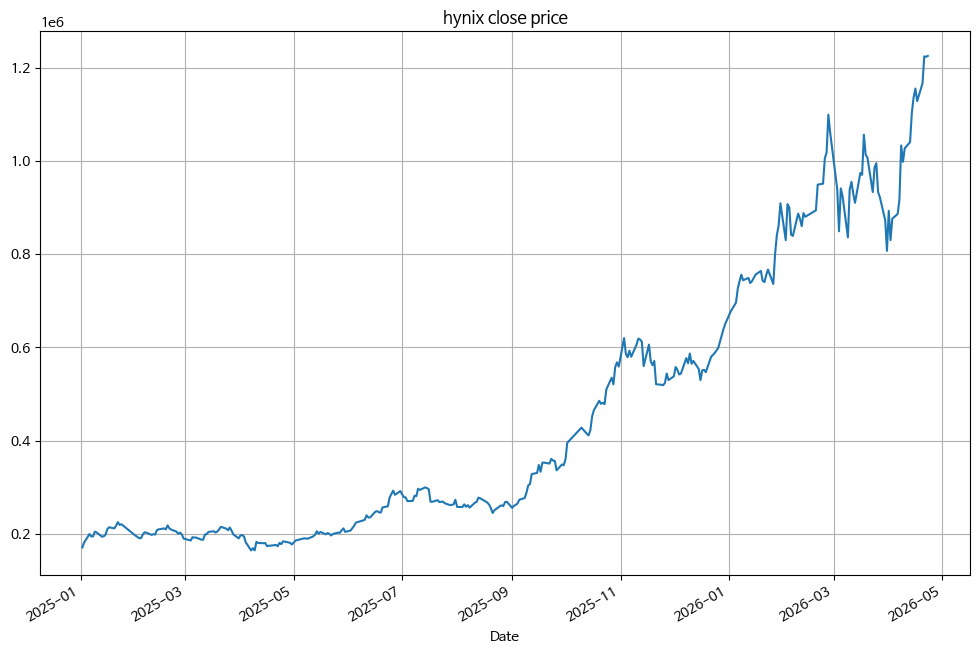

In [37]:
# 종가를 기준으로 그래프 생성
df['Close'].plot(figsize=(12, 8), title = 'hynix close price')
plt.grid(True)
plt.show()